# Heart Disease Dataset - Exploratory Data Analysis

# Heart Disease Risk Prediction
### Exploratory Data Analysis

This notebook presents an exploratory data analysis of a heart disease dataset.  
The goal is to understand the structure of the data, inspect data quality, explore variable distributions, and identify potential relationships between clinical features and the target outcome.

Import libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

sns.set_style("whitegrid")

Load dataset

In [6]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [7]:
df = pd.read_csv("heart.csv")

Initial inspection

In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [9]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [10]:
df.shape

(1025, 14)

In [11]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Missing values and duplicates

In [13]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [14]:
df.duplicated().sum()

np.int64(723)

In [15]:
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)


We checked the dataset for missing values and duplicate records to ensure data quality before proceeding with further analysis.

The dataset does not contain missing values.  
A small number of duplicate rows were detected and removed to avoid potential bias in the analysis.



## Descriptive Statistics
We examine summary statistics to understand the distribution and range of numerical variables.

In [18]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Target Variable Distribution

We examine the distribution of the target variable to understand the balance between the two classes in the dataset.

In [19]:
df["target"].value_counts()

,count
target,
1,164
0,138


In [20]:
df["target"].value_counts(normalize=True) * 100

,proportion
target,
1,54.304636
0,45.695364


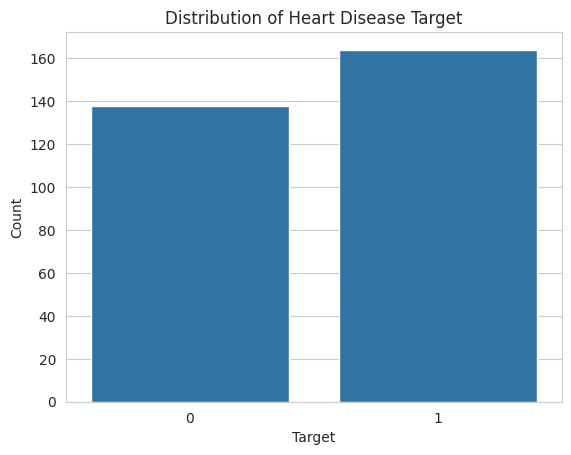

In [21]:
sns.countplot(x="target", data=df)
plt.title("Distribution of Heart Disease Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

The dataset contains approximately 54% patients with heart disease and 46% without heart disease.  
This indicates that the dataset is relatively balanced, which is beneficial for training classification models.

## Univariate Analysis

In this section, we explore the distribution of individual variables to better understand their ranges and patterns.

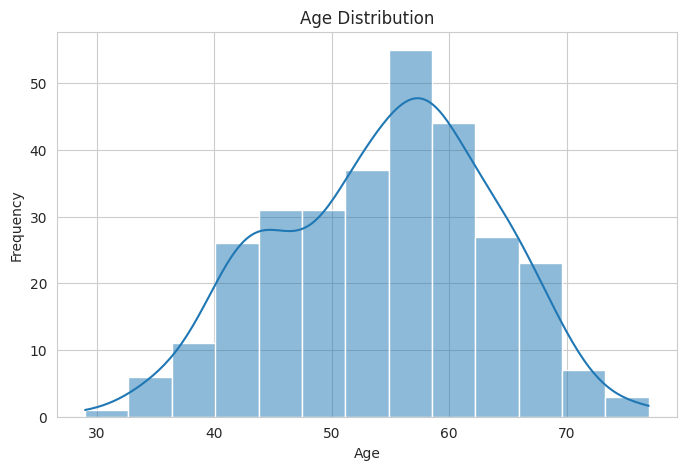

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The age distribution appears approximately normal, with most patients falling between 50 and 60 years of age.  
The dataset covers a wide age range, roughly from 30 to 77 years, indicating a diverse patient population.

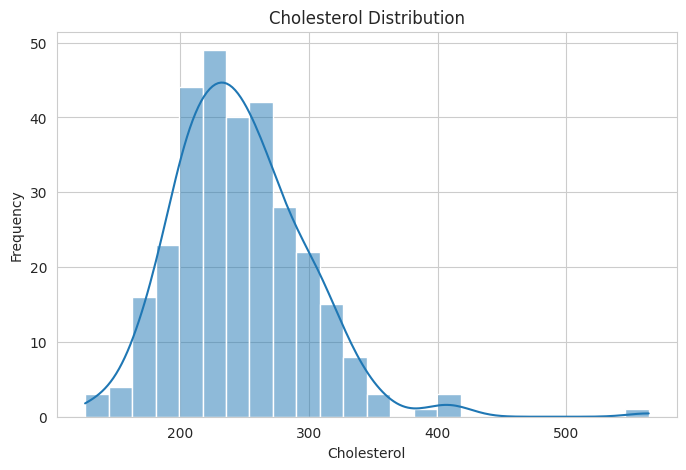

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["chol"], kde=True)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.show()

Most cholesterol values fall between 200 and 300.  
The distribution is slightly right-skewed, with a few very high values that may represent potential outliers.

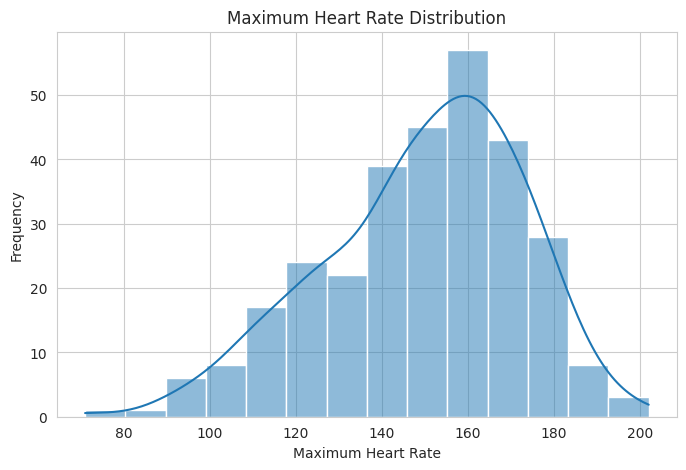

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df["thalach"], kde=True)
plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Frequency")
plt.show()

Maximum heart rate values show an approximately normal distribution, with most patients falling between 150 and 170.

The variable spans a wide range but does not appear to contain extreme outliers.

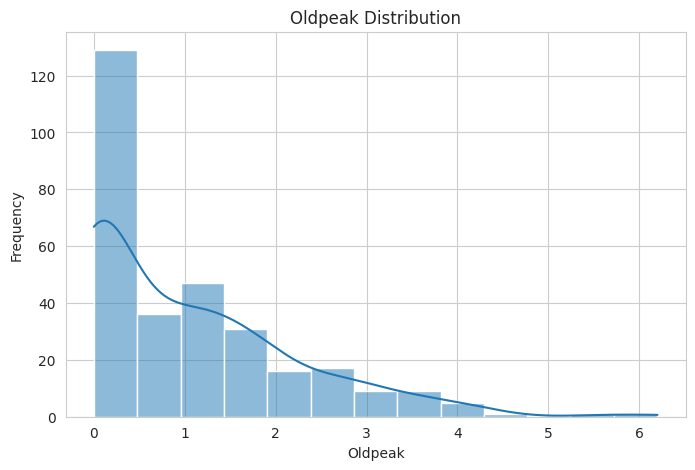

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df["oldpeak"], kde=True)
plt.title("Oldpeak Distribution")
plt.xlabel("Oldpeak")
plt.ylabel("Frequency")
plt.show()

The oldpeak distribution is highly right-skewed, with most values concentrated between 0 and 1.

A few observations show higher values, which may represent potential outliers.

Higher oldpeak values represent greater ST depression during exercise, which may be associated with reduced blood flow to the heart.

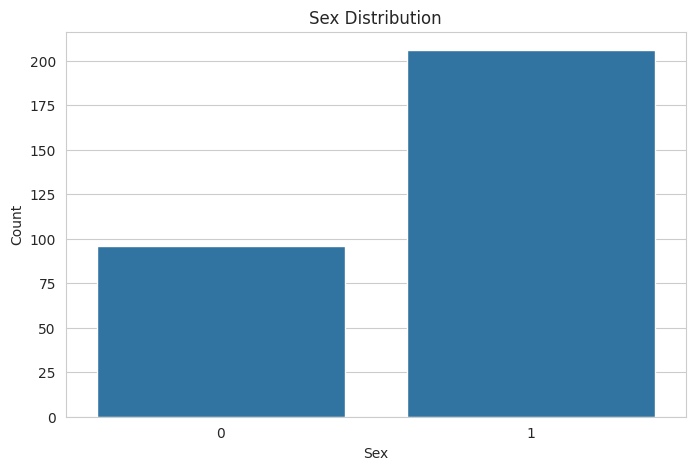

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x="sex", data=df)
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

The dataset contains considerably more male patients than female patients.  
This indicates that the dataset is not balanced with respect to sex, which may influence the patterns observed in subsequent analyses.
This pattern may reflect the higher prevalence of cardiovascular disease in male populations reported in clinical studies.

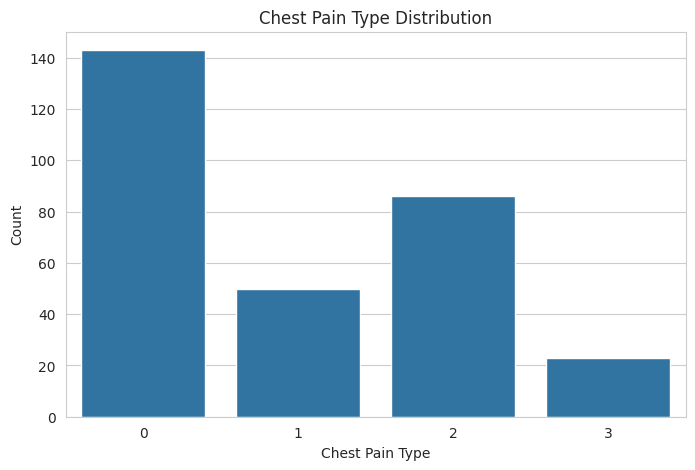

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(x="cp", data=df)
plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

The chest pain variable represents four different types of chest pain experienced by patients.

The distribution shows that the most common category in the dataset is typical angina (cp = 0), followed by non-anginal pain (cp = 2). The categories atypical angina (cp = 1) and asymptomatic (cp = 3) appear less frequently.

This variation in chest pain types may provide useful information when analyzing potential relationships with heart disease outcomes.
Chest pain characteristics are clinically important indicators when evaluating potential cardiovascular conditions.

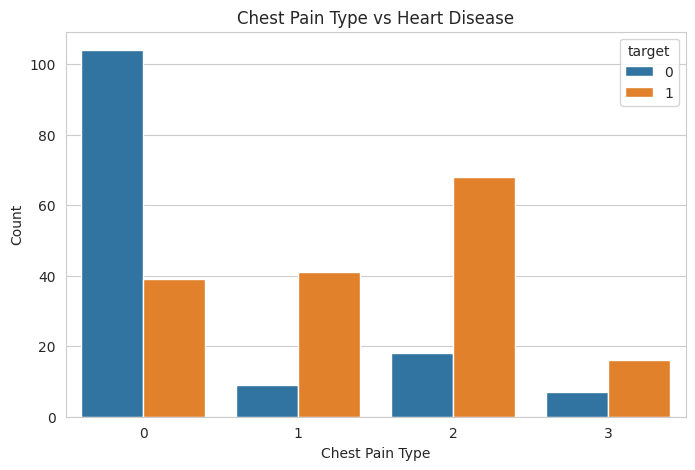

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x="cp", hue="target", data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

## Chest Pain Type vs Heart Disease

The relationship between chest pain type and heart disease shows noticeable differences across categories.

Patients with cp = 2 (non-anginal pain) and cp = 1 (atypical angina) appear to have a higher proportion of heart disease cases (target = 1). In contrast, cp = 0 (typical angina) shows a higher number of patients without heart disease.

These patterns suggest that chest pain type may be an informative feature for predicting heart disease in this dataset.

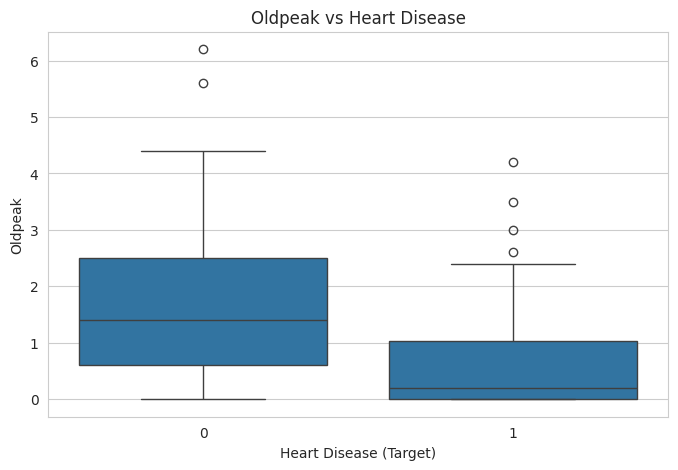

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="oldpeak", data=df)
plt.title("Oldpeak vs Heart Disease")
plt.xlabel("Heart Disease (Target)")
plt.ylabel("Oldpeak")
plt.show()

## Oldpeak vs Heart Disease

The distribution of the oldpeak variable differs between patients with and without heart disease.

Patients without heart disease (target = 0) tend to show higher median oldpeak values and greater variability compared to patients with heart disease (target = 1).

Several outliers are visible in both groups, indicating that some individuals exhibit substantially higher ST depression values during exercise.

These differences suggest that oldpeak may contain useful information for distinguishing between the two groups.

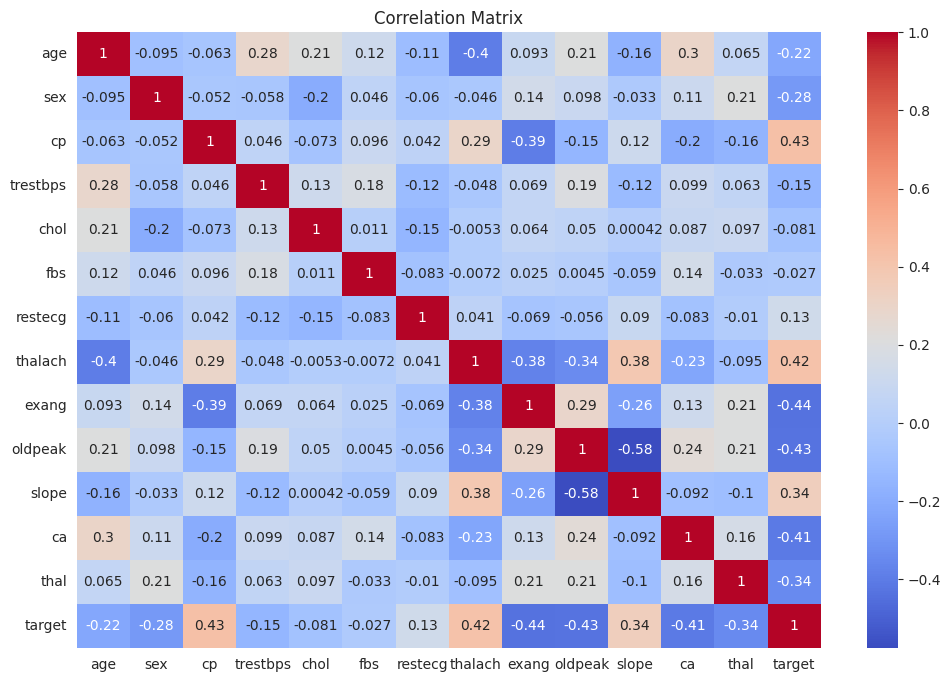

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Correlation Analysis

The correlation matrix provides an overview of relationships between variables in the dataset.

Several variables show moderate correlations with the target variable. In particular, chest pain type (cp), maximum heart rate (thalach), and slope display positive correlations with heart disease presence.

On the other hand, exercise induced angina (exang), oldpeak, and number of major vessels (ca) show negative correlations with the target variable.

Overall, no extremely strong correlations are observed between predictors, suggesting a relatively low risk of multicollinearity.

## Key Findings from Exploratory Data Analysis

The exploratory data analysis provided several insights into the structure and characteristics of the dataset.

First, the dataset contains no missing values and duplicate rows were removed during preprocessing, ensuring good data quality for further analysis.

The target variable is relatively balanced, with approximately 54% of patients diagnosed with heart disease and 46% without the condition. This balance is beneficial for building classification models.

Age and cholesterol values show noticeable variability across patients. Cholesterol in particular displays a right-skewed distribution with several potential outliers. Maximum heart rate appears approximately normally distributed, while the oldpeak variable shows strong right skewness, with most observations close to zero.

Categorical variables reveal additional patterns. The dataset contains more male patients than female patients. The distribution of chest pain types varies considerably, with typical angina being the most common category.

When examining relationships with the target variable, several features show clear differences between groups. In particular, chest pain type (cp), maximum heart rate (thalach), and slope appear positively associated with heart disease presence, while exercise induced angina (exang), oldpeak, and the number of major vessels (ca) show negative correlations with the target.

The correlation analysis indicates that several variables may be useful predictors of heart disease, while no extremely strong correlations exist between predictors, suggesting a relatively low risk of multicollinearity.

Overall, the exploratory analysis suggests that clinical variables related to chest pain characteristics, exercise response, and cardiac function may play an important role in predicting heart disease in this dataset.

# Machine Learning Model

In this section, we build a machine learning model to predict the presence of heart disease using the clinical variables from the dataset.

In [32]:
X = df.drop("target", axis=1)
y = df["target"]

The dataset is split into input features (X) and the target variable (y).  
The target variable represents whether a patient has heart disease.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset is divided into training and testing sets.  
80% of the data is used for training the model, while 20% is reserved for evaluating model performance.

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Logistic Regression is used as the first classification model to predict the presence of heart disease.

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.7868852459016393
              precision    recall  f1-score   support

           0       0.88      0.69      0.77        32
           1       0.72      0.90      0.80        29

    accuracy                           0.79        61
   macro avg       0.80      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



## Model Performance

The Logistic Regression model achieved an accuracy of approximately **79%** on the test dataset.

Looking deeper into the classification metrics:

- The model shows **high precision for class 0 (0.88)**, meaning that when the model predicts absence of heart disease, it is usually correct.
- For patients with heart disease (class 1), the model achieved **high recall (0.90)**, indicating that the model successfully identifies most of the positive cases.

This is an important property in medical prediction tasks, where identifying patients with potential disease is often more critical than minimizing false positives.

The F1-scores for both classes are relatively balanced (0.77 and 0.80), suggesting that the model performs consistently across both classes.

Overall, the results indicate that Logistic Regression provides a solid baseline model for predicting heart disease using the available clinical features.

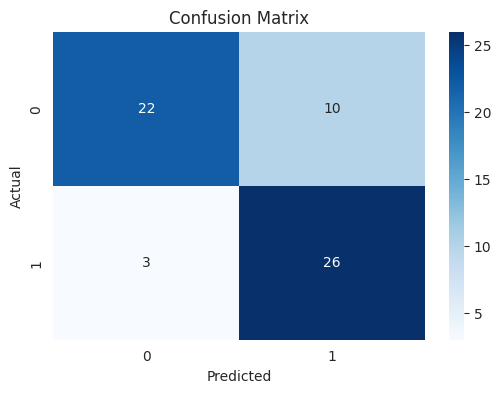

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows how the model performs when predicting heart disease.

The model correctly identified **26 patients with heart disease** and **22 patients without the disease**.

There were **10 false positive predictions**, where the model predicted heart disease for patients who were actually healthy. While this may lead to unnecessary follow-up tests, it is generally less problematic in medical screening.

Importantly, the model produced only **3 false negatives**, meaning very few patients with heart disease were missed. This contributes to the high recall score for the positive class.

Overall, the model demonstrates a good balance between detecting heart disease cases and correctly identifying healthy patients.

In [38]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
2,cp,0.962750
6,restecg,0.856720
10,slope,0.475651
7,thalach,0.022258
4,chol,-0.001296
0,age,-0.003878
3,trestbps,-0.033223
5,fbs,-0.133224
8,exang,-0.482341
11,ca,-0.571830


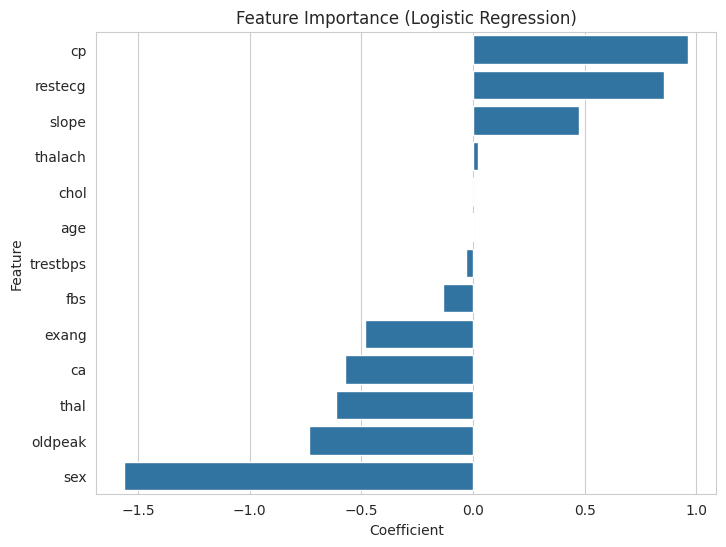

In [39]:
plt.figure(figsize=(8,6))
sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coefficients
)

plt.title("Feature Importance (Logistic Regression)")
plt.show()

## Feature Importance Interpretation

The logistic regression coefficients reveal which clinical variables contribute most to the prediction of heart disease.

Among the strongest positive contributors are chest pain type (cp), resting ECG results (restecg), and ST slope, suggesting that characteristics related to cardiac stress response play an important role in the model.

Some variables show negative coefficients, such as sex, oldpeak, and thal. This indicates that higher values of these features are associated with a lower predicted probability of heart disease within this dataset.

Interestingly, certain variables such as cholesterol appear to have minimal influence on the model, suggesting that they may not provide strong predictive signal when combined with other clinical features.

Overall, the model appears to rely most heavily on features describing chest pain characteristics and cardiac response to stress.

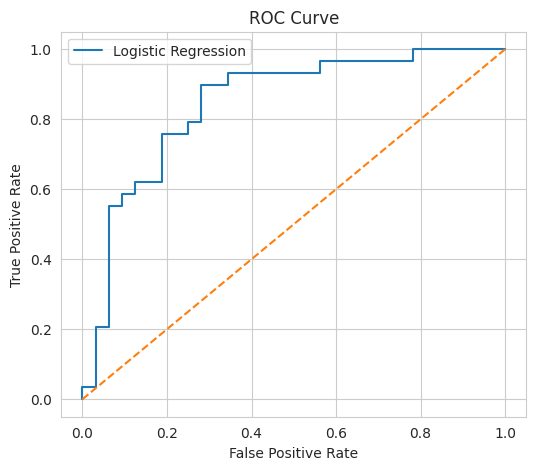

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [41]:
auc = roc_auc_score(y_test, y_prob)
print("AUC score:", auc)

AUC score: 0.84375


## ROC Curve and AUC

The ROC curve illustrates the trade-off between the true positive rate and false positive rate across different classification thresholds.

The Logistic Regression model achieved an **AUC score of 0.84**, indicating strong ability to distinguish between patients with and without heart disease.

An AUC above 0.8 generally indicates good model performance, suggesting that the model captures meaningful patterns in the clinical variables used for prediction.